# **Demonstration Workflow**

### This demo is designed to provide a brief start-to-finish example of the capabilities of this toolkit, and how it can be used to integrate and process outputs from multiple data acquisition sources, including Bonsai, returning them in a format ready for subsequent data analysis in <code>movement</code>

## **1) The Example Experimental Setup**

#### For the purposes of this demo, we shall take the case of an experimental setup consisting of the following:
a) Harp Devices:
    - Two Behavior Boards, each connected to three nosepoke peripherals
    - A SoundCard
    - A camera connected to the Harp control board

b) A Neuropixel probe.

c) Pose estimation data from DeepLabCut or SLEAP, based on the video camera

#### We also have additional information logs stored by Bonsai that we may wish to extract:

a) ExperimentEvents: a .csv file containing experiment logs from our Bonsai workflow

b) SessionSettings: a .jsonl file containing session and trial metadata based on our Bonsai workflow

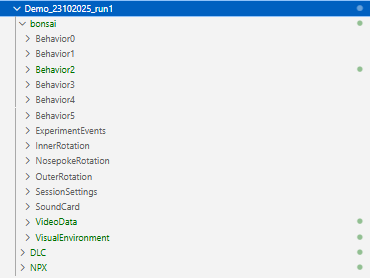

# **2) Processing Data from Harp Devices**



## 2.1| Organising Data from Multiple Devices and Registers By Defining Devices, LocalIDs, and Peripheral

### **Example:**
- The example below, we demonstrate an experimental setup with:
    - Two Behaviour boards (Behaviour0 and Behaviour1), each with three nosepoke devices connected to it. 
    - A SoundCard
    - Video data- a .avi file and a .csv file
    - session settings (.jsonl)
    - ExperimentEvents (.csv)


In [1]:
#=== Setup
import pandas as pd
import numpy as np
import harp
import os
from pathlib import Path
import re
import xarray as xr
import yaml
experiment_directory_path= './Bonsai_logs/Demo_23102025_run1/bonsai'


## 2.2|Setting Up the Bonsai Utilities


When we only have one device of a particular type that we are interested in, the process of automatically extracting data from this is straightforward. We can take advantage of the base class in <code>Devices</code> to quickly make a simple custom class that can convert all the '.bin' files into readable formats. 

To do this, we simply need to specify the following arguments:

**Arguments:**
- **experiment_directory_path** (str): Path to the root directory of the Bonsai experiment
- **harp_device_yaml_path** (str): Path to the YAML file for the specific harp device. If None, the object will attempt to find it automatically within the experiment directory.
- **device_type** (str): Subfolder prefix to be loaded (e.g. 'Behavior'). Device type must match that of the device schema yaml file.
- **device_list** (list): List of devices names to be loaded.
- **device_IDs** (list): List of device IDs to be loaded.
- **device_registers_dict** (dict): Dictionary where keys are device names and values are lists of register addresses to be loaded for each device.
- **da_type_dict** (dict): Dictionary where keys are output names and values are the device, register_address pairs. 
- **verbose** (bool): If True, prints detailed output during the data extraction process.

### **Example 1: SoundCard**

In [2]:
#===== SoundCard Class =====================================================
from Data_Imports.Helper_Functions.Helper_functions import Device_DataArrays
class SoundCard(Device_DataArrays):
    '''
    Class to manage loading and processing of SoundCard data from HARP devices.
    Inherits from Device_DataArrays class.
    '''

    def __init__(self,
                 experimental_directory_path= None,         # Path to experimental directory (str or Path)  
                 harp_device_yaml_path= './soundcard.yml',            # Path to harp_device yaml file (str or Path). If None, will attempt to find in experimental_directory_path.
                 device_type= 'SoundCard',                  # Subfolder Prefix type to load (str). Must be exact prefix. E.g. 'Behavior' will load 'Behavior0', 'Behavior1', etc. Should not be device, but device_type used for consistency across methods.
                 device_list= ['SoundCard'],                    # List of device names to load (list of str)
                 device_IDs= {'SoundCard': 'SoundCard0'},                     # List of device IDs to load (list of int or str)
                 device_registers_dict= {'SoundCard': ['8', '32', '33', '35']},      # Dict of device registers to load (dict of str: list of str). E.g. {'DeviceName': ['Register1', 'Register2'],...}. If None, will load all registers for the specified devices.
                 da_type_dict= {'PlaySoundFreq': ('SoundCard', '32'),'StopLog': ('SoundCard', '33'),'AttenuationRight': ('SoundCard', '35')},
                 verbose= False,                            # If True, prints detailed output during processing (bool)
                    ):
    
        super(SoundCard, self).__init__(experimental_directory_path= experimental_directory_path,
                                       harp_device_yaml_path= harp_device_yaml_path,
                                       device_type= device_type,
                                       device_list= device_list,
                                       device_IDs= device_IDs,
                                       device_registers_dict= device_registers_dict,
                                       da_type_dict= da_type_dict,
                                       verbose= verbose
                                        )

#### **We can then either call this directly from the active notebook or python file, or we can add it as a custom class in it's own .py file if we wish to reuse this again**

In [3]:
## Example Import
# from Devices.SoundCard import SoundCard
soundcard= SoundCard(experimental_directory_path= experiment_directory_path)

#==== Get data array dictionary from soundcard object 
soundcard_data= soundcard.device_da_dict

#==== Print keys found in soundcard_data
print(f'Keys in soundcard_data: {list(soundcard_data.keys())}')

#==== Display data arrays for each key
display(soundcard_data['PlaySoundFreq'].to_dataframe())
display(soundcard_data['StopLog'].to_dataframe())
display(soundcard_data['AttenuationRight'].to_dataframe())

Keys in soundcard_data: ['PlaySoundFreq', 'StopLog', 'AttenuationRight']


,PlaySoundOrFrequency
Time,
7130.936480,880
7130.936896,880


,Stop
Time,
7130.974496,1


,AttenuationRight
Time,
7130.937504,1000


## **Example 2: Nosepokes**
- Harp devices. such as Behaviour boards and Sound cards, have a range of different input and output ports. These ports are used to communicate between harp devices and the peripherals connected to them, such as nosepokes. 
- When analysing experimental data, users may find that they wish to collate data that is sent to or from these peripherals from multiple devices and registers into a single, unified dataframe for easier analysis.

- To facilitate this process, we introduce the following concepts:
    - **Device**: A specific harp device within an experiment directory (e.g. Behaviour1)
    - **LocalID**: The name of a particular input or output port on a harp device that communicates with the peripheral and corresponds to a specific column in the register dataframe (e.g. DIPort0-2)
    - **Peripheral**: A unique identifier for a peripheral connected to a harp device (e.g. Nosepoke0)
    - **data_key**: A user-defined key that refers to the particular type of data that is being collated. This is important for peripherals such as nosepokes, which may have multiple sets of peripheral: device-localID pairs of interest. 

### We can automate the extraction of this by using the base class in <code>MultiDevices</code>. 
- By defining the relationships between these global peripheral names and devices and localIDs, we can then extract and reformat data from the nested dictionary structures created in Part 1 into unified dataframes for easier analysis.

- Users can then define the following dictionaries, which can then be passed to the relevant functions to extract and restructure data:
    1. **device_list**: a list of device names (as strings) corresponding to devices of the specified type within the experiment directory.
    2. **device_registers_dict**: a key-pair dictionary where:
        - Keys are device names (as strings) corresponding to devices of the specified type within the experiment directory.
        - Values are lists of register addresses (as integers or strings) corresponding to the registers of interest for each device.
    3. **peripheral_list**: a list of global peripheral names (as strings) corresponding to the peripherals of interest.
    4. **peripheral_localIDs**: a key-pair dictionary where keys are the data_key names and values are the localIDs for that data_key.
    5. **peripheral_registerIDs**: a key-pair dictionary where the keys are the localID names and the values are the corresponding register addresses.



- Each nosepoke has:
    1. Activation data recorded under Register 32 (DigitalInputState), with localIDs DIPort0-2
    2. LED activations, outputs from the device as DOPort0-2 on register 34

In [4]:
#======= Defining the Device Configuration

harp_device_yaml_path= './device.yml'

device_list= ['Behavior0', 'Behavior1']
device_type= 'Behavior'
device_registers_dict= {
    'Behavior0': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
    'Behavior1': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
}

channel_list= ['Nosepoke0',
               'Nosepoke1',
               'Nosepoke2',
               'Nosepoke3',
               'Nosepoke4',
               'Nosepoke5',
]


Nosepoke_Activations_localIDs= ['DIPort0',
                                'DIPort1',
                                'DIPort2',
]

Nosepoke_LED_Activations_localIDs= ['DOPort0',
                                    'DOPort1',
                                    'DOPort2',
]



channel_type_localIDs= {
    'Activations': Nosepoke_Activations_localIDs,
    'LED_Activations': Nosepoke_LED_Activations_localIDs,

}


Activations_localID_register_dict= {
    'DIPort0': '32',
    'DIPort1': '32',
    'DIPort2': '32',
}
LED_Activations_localID_register_dict= {
    'DOPort0': '34',
    'DOPort1': '34',
    'DOPort2': '34',
}


channel_type_registerIDs= {
    'Activations': Activations_localID_register_dict,
    'LED_Activations': LED_Activations_localID_register_dict,
}

data_keys= ['Activations', 'LED_Activations']

In [5]:

data_key= list(channel_type_localIDs.keys())[1]
channel_ref_dict= {
    f'{channel_list[0]}':  (f'{device_list[0]}', f'{channel_type_localIDs[data_key][0]}'),
    f'{channel_list[1]}':  (f'{device_list[0]}', f'{channel_type_localIDs[data_key][1]}'),
    f'{channel_list[2]}':  (f'{device_list[0]}', f'{channel_type_localIDs[data_key][2]}'),

    f'{channel_list[3]}':  (f'{device_list[1]}', f'{channel_type_localIDs[data_key][0]}'),
    f'{channel_list[4]}':  (f'{device_list[1]}', f'{channel_type_localIDs[data_key][1]}'),
    f'{channel_list[5]}':  (f'{device_list[1]}', f'{channel_type_localIDs[data_key][2]}'),
}

In [6]:

from Data_Imports.Helper_Functions.Helper_functions import BehaviorNosepoke

core_config= {
    'experimental_directory_path': experiment_directory_path,
    'harp_device_yaml_path': harp_device_yaml_path,
    'device_type': device_type,
    'device_list': device_list,
    'device_IDs': None,
    'device_registers_dict': device_registers_dict,
    'channel_list': channel_list,
    'channel_type_localIDs': channel_type_localIDs,
    'channel_type_registerIDs': channel_type_registerIDs,
    'type_keys': data_keys,
}

optional_config= {
    'test_help_values': False,
    'fill_value': None,
    'verbose': False,
    'only_errors': False,
    'validate_devices': False,
    'validate_deviceIDs': False,
    'validate_device_registers': False,
    'validate_register_channels': False,
    'fill_values': None,
    'typekey_da_attributes': None,
    'typekey_lookup_attributes': None,
}
Example_version= BehaviorNosepoke(**core_config, **optional_config)

IndexError: list index out of range

In [7]:
from Refactor.MultiDevices.multidevice import BehaviorNosepoke
# from Data_Imports.Helper_Functions.Helper_functions import BehaviorNosepoke

behavior_nosepoke= BehaviorNosepoke(
    experimental_directory_path= experiment_directory_path,
    harp_device_yaml_path= harp_device_yaml_path,
    device_list= device_list,
    device_registers_dict= device_registers_dict,
    channel_list= channel_list,
    channel_type_localIDs= channel_type_localIDs,
    channel_type_registerIDs= channel_type_registerIDs,
    channel_ref_dict= channel_ref_dict,
    verbose= True
)

/home/callum/Keshavarzi-Lab-Workspace/Movement-Workflow-Development/Refactor/LookupArrays/lookup_arrays.py:536: AccessorRegistrationWarning: registration of accessor <class 'Refactor.LookupArrays.lookup_arrays.CDLAccessor'> under name 'cdl' for type <class 'xarray.core.dataarray.DataArray'> is overriding a preexisting attribute with the same name.
  @xr.register_dataarray_accessor('cdl')
/home/callum/Keshavarzi-Lab-Workspace/Movement-Workflow-Development/Refactor/LookupArrays/lookup_arrays.py:681: AccessorRegistrationWarning: registration of accessor <class 'Refactor.LookupArrays.lookup_arrays.TimeIndexerAccessor'> under name 'time_indexer' for type <class 'xarray.core.dataarray.DataArray'> is overriding a preexisting attribute with the same name.
  @xr.register_dataarray_accessor('time_indexer')


ValueError: harp_device_yaml_path must be a string or Path object.